# Notebook 03: Baseline & Linear Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load Data & Setup

In [ ]:
train = pd.read_csv('clean_data/train.csv', parse_dates=['week_start'])
test = pd.read_csv('clean_data/test.csv', parse_dates=['week_start'])

cat_cols = [c for c in train.columns if c.startswith('cat_id_')]
store_cols = [c for c in train.columns if c.startswith('store_id_')]

for df in [train, test]:
    df['cat_id'] = df[cat_cols].idxmax(axis=1).str.replace('cat_id_', '')
    df['store_id'] = df[store_cols].idxmax(axis=1).str.replace('store_id_', '')

target = 'weekly_units'
drop_cols = (['wm_yr_wk', 'week_start', 'n_days', 'month', 'week_of_year', 
              'cat_id', 'store_id', target]
             + cat_cols + store_cols 
             + [c for c in train.columns if c.startswith('state_id_')])
feature_cols = [c for c in train.columns if c not in drop_cols]

combos = sorted(train.groupby(['store_id', 'cat_id']).groups.keys())

In [ ]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

def run_model_per_combo(model_class, model_name, model_kwargs=None):
    if model_kwargs is None:
        model_kwargs = {}
    
    all_preds, combo_results = [], []
    
    for store, cat in combos:
        tr = train[(train['store_id'] == store) & (train['cat_id'] == cat)]
        te = test[(test['store_id'] == store) & (test['cat_id'] == cat)]
        
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(tr[feature_cols])
        X_te_s = scaler.transform(te[feature_cols])
        
        model = model_class(**model_kwargs)
        model.fit(X_tr_s, tr[target])
        preds = model.predict(X_te_s)
        
        metrics = calc_metrics(te[target], preds)
        metrics['store_id'] = store
        metrics['cat_id'] = cat
        combo_results.append(metrics)
        
        pred_df = te[['week_start', 'store_id', 'cat_id']].copy()
        pred_df['actual'] = te[target].values
        pred_df['predicted'] = preds
        all_preds.append(pred_df)
    
    all_preds_df = pd.concat(all_preds, ignore_index=True)
    combo_df = pd.DataFrame(combo_results)
    overall = calc_metrics(all_preds_df['actual'], all_preds_df['predicted'])
    
    print(f"{model_name:32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  "
          f"MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
    
    return all_preds_df, combo_df, overall

all_results = []

## 2. Naive Baselines

In [ ]:
def run_naive(pred_col, name):
    preds_df = test[['week_start', 'store_id', 'cat_id']].copy()
    preds_df['actual'] = test[target].values
    preds_df['predicted'] = test[pred_col].values
    
    overall = calc_metrics(preds_df['actual'], preds_df['predicted'])
    print(f"{name:32s}  MAE={overall['MAE']:>7,.0f}  RMSE={overall['RMSE']:>7,.0f}  "
          f"MAPE={overall['MAPE']:>5.1f}%  R²={overall['R2']:.4f}")
    
    combo_df = preds_df.groupby(['store_id', 'cat_id']).apply(
        lambda g: pd.Series(calc_metrics(g['actual'], g['predicted']))).reset_index()
    
    return preds_df, combo_df, overall

pred_naive_lw, combo_naive_lw, res = run_naive('lag_1', 'Naive: Last Week')
all_results.append({'model': 'Naive: Last Week', **res})

pred_naive_ly, combo_naive_ly, res = run_naive('lag_52', 'Naive: Same Week Last Year')
all_results.append({'model': 'Naive: Same Week Last Year', **res})

pred_naive_ra, combo_naive_ra, res = run_naive('rolling_mean_4', 'Naive: 4-Week Avg')
all_results.append({'model': 'Naive: 4-Week Avg', **res})

## 3. Linear Regression (OLS)

~217 training rows per model, 23 features. Ratio is tight for OLS.

In [ ]:
pred_ols, combo_ols, res = run_model_per_combo(LinearRegression, 'Linear Regression (OLS)')
all_results.append({'model': 'Linear Regression (OLS)', **res})

## 4. Ridge Regression (L2)

Each of the 30 models picks its own alpha via 5-fold CV.

In [ ]:
pred_ridge, combo_ridge, res = run_model_per_combo(
    RidgeCV, 'Ridge (CV alpha)', 
    model_kwargs={'alphas': np.logspace(-2, 5, 50), 'cv': 5}
)
all_results.append({'model': 'Ridge (CV alpha)', **res})

## 5. Lasso Regression (L1)

Custom loop to track per-model feature selection.

In [ ]:
all_lasso_preds = []
combo_lasso = []
lasso_feature_usage = pd.DataFrame(0, index=feature_cols, columns=[f"{s}_{c}" for s, c in combos])

for store, cat in combos:
    tr = train[(train['store_id'] == store) & (train['cat_id'] == cat)]
    te = test[(test['store_id'] == store) & (test['cat_id'] == cat)]
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(tr[feature_cols])
    X_te_s = scaler.transform(te[feature_cols])
    
    lasso = LassoCV(alphas=np.logspace(-1, 4, 50), cv=5, max_iter=10000)
    lasso.fit(X_tr_s, tr[target])
    preds = lasso.predict(X_te_s)
    
    metrics = calc_metrics(te[target], preds)
    metrics['store_id'] = store
    metrics['cat_id'] = cat
    combo_lasso.append(metrics)
    
    pred_df = te[['week_start', 'store_id', 'cat_id']].copy()
    pred_df['actual'] = te[target].values
    pred_df['predicted'] = preds
    all_lasso_preds.append(pred_df)
    
    coefs = pd.Series(lasso.coef_, index=feature_cols)
    lasso_feature_usage[f"{store}_{cat}"] = (coefs != 0).astype(int)

pred_lasso = pd.concat(all_lasso_preds, ignore_index=True)
combo_lasso = pd.DataFrame(combo_lasso)
lasso_overall = calc_metrics(pred_lasso['actual'], pred_lasso['predicted'])

print(f"{'Lasso (CV alpha)':32s}  MAE={lasso_overall['MAE']:>7,.0f}  RMSE={lasso_overall['RMSE']:>7,.0f}  "
      f"MAPE={lasso_overall['MAPE']:>5.1f}%  R²={lasso_overall['R2']:.4f}")
all_results.append({'model': 'Lasso (CV alpha)', **lasso_overall})

In [ ]:
usage_count = lasso_feature_usage.sum(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['salmon' if v < 15 else 'steelblue' for v in usage_count]
usage_count.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Models using feature (out of 30)')
ax.set_title('Lasso Feature Selection Across 30 Models')
ax.axvline(15, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [ ]:
results_df = pd.DataFrame(all_results).set_index('model')
results_df = results_df.round({'MAE': 0, 'RMSE': 0, 'MAPE': 1, 'R2': 4})
results_df = results_df.sort_values('MAE')
results_df

,MAE,RMSE,MAPE,R2
model,,,,
Ridge (CV alpha),406.0,755.0,4.2,0.9913
Lasso (CV alpha),414.0,733.0,4.3,0.9918
Linear Regression (OLS),491.0,932.0,4.8,0.9867
Naive: 4-Week Avg,577.0,1111.0,5.0,0.9811
Naive: Last Week,655.0,1369.0,6.0,0.9713
Naive: Same Week Last Year,1532.0,3086.0,12.5,0.8543


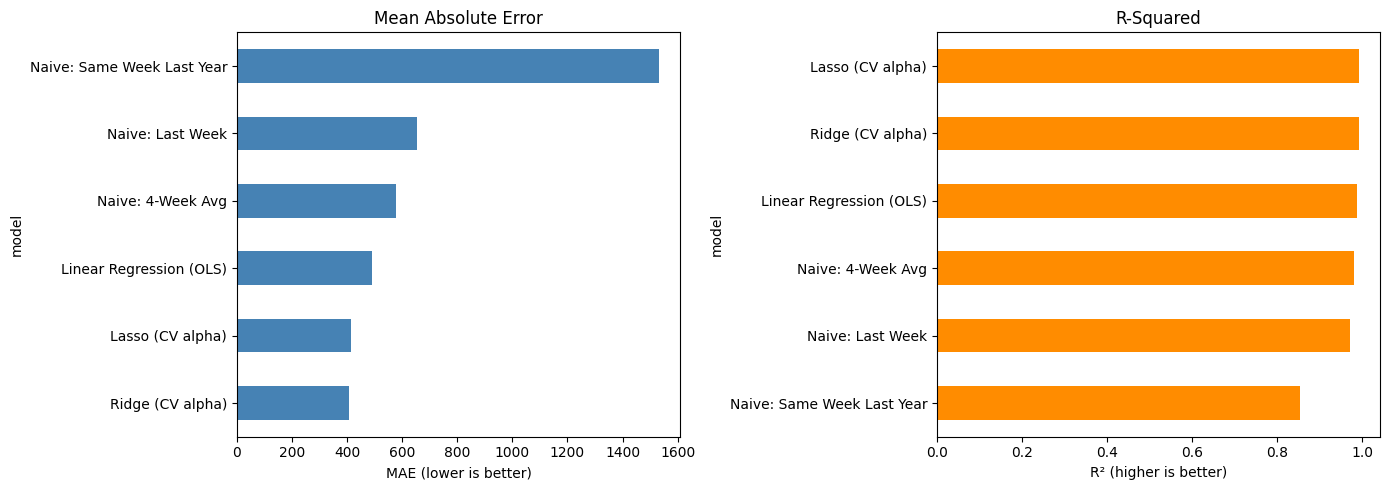

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['MAE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('MAE (lower is better)')
axes[0].set_title('Mean Absolute Error')

results_df['R2'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('R-Squared')

plt.tight_layout()
plt.show()

## 7. Error Analysis

In [ ]:
test_analysis = pred_ridge.copy()
test_analysis['error'] = test_analysis['actual'] - test_analysis['predicted']
test_analysis['abs_pct_error'] = (np.abs(test_analysis['error']) / test_analysis['actual']) * 100
test_analysis.head()

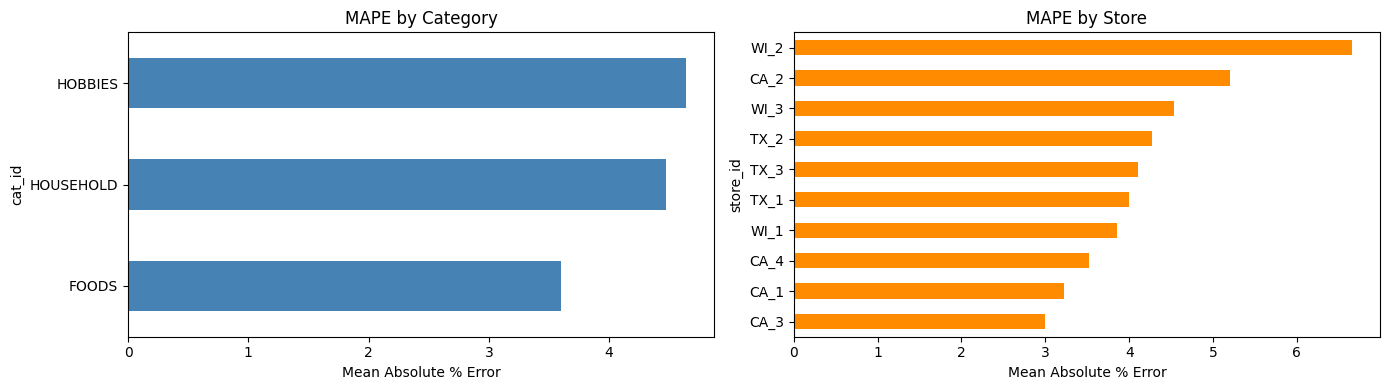

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

test_analysis.groupby('cat_id')['abs_pct_error'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Mean Absolute % Error')
axes[0].set_title('MAPE by Category')

test_analysis.groupby('store_id')['abs_pct_error'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].set_xlabel('Mean Absolute % Error')
axes[1].set_title('MAPE by Store')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, cat in zip(axes, sorted(test_analysis['cat_id'].unique())):
    subset = test_analysis[test_analysis['cat_id'] == cat]
    by_week = subset.groupby('week_start')[['actual', 'predicted']].mean()
    
    ax.plot(by_week.index, by_week['actual'], 'o-', label='Actual', markersize=5)
    ax.plot(by_week.index, by_week['predicted'], 's--', label='Predicted', markersize=5, alpha=0.8)
    ax.set_title(cat)
    ax.set_xlabel('Week')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Avg Weekly Units')
fig.suptitle('Actual vs. Predicted (Ridge) — Test Period', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_analysis['error'], bins=30, edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Prediction Error (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={test_analysis["error"].mean():.0f}, std={test_analysis["error"].std():.0f})')
plt.tight_layout()
plt.show()

## 8. MAPE Heatmap (Store x Category)

In [ ]:
mape_pivot = combo_ridge.pivot_table(index='store_id', columns='cat_id', values='MAPE')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mape_pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(mape_pivot.columns)))
ax.set_xticklabels(mape_pivot.columns)
ax.set_yticks(range(len(mape_pivot.index)))
ax.set_yticklabels(mape_pivot.index)

for i in range(len(mape_pivot.index)):
    for j in range(len(mape_pivot.columns)):
        ax.text(j, i, f'{mape_pivot.values[i, j]:.1f}%', ha='center', va='center', fontsize=9)

ax.set_title('Ridge MAPE (%) by Store x Category')
fig.colorbar(im, ax=ax, shrink=0.8, label='MAPE %')
plt.tight_layout()
plt.show()

## 9. Takeaways

- Per-store-category models outperform the pooled model (MAPE 4.2% vs 5.3%).
- Ridge is the best linear model here (MAE=406).
- The 4-week rolling average baseline is strong at 5.0% MAPE. The marginal improvement from linear models is ~0.8pp.
- FOODS easiest to forecast (avg MAPE 3.6%), HOBBIES and HOUSEHOLD around 4.5%.
- WI_2 is the hardest store across categories.
- Lasso feature selection: `lag_1` (28/30), `rolling_mean_4` (25/30), `lag_52` (21/30) are the core. `cat_share_lag1` (20/30) and `snap_days` (19/30) earn their spot. `momentum` (2/30) is dead. Cyclical encodings and price features are situational.
- R²=0.99 overall. The bar for tree-based models is set.